# Aggregations: Min, Max, and Everything In Between

Often when faced with a large amount of data, a first step is to compute summary statistics for the data in question.
Common summary stats are the <b>mean</b> and <b>standard deviation</b>, which allow you to summarize the "typical" values in a dataset, but other aggregates are useful as well (the <em>sum, product, median, minimum and maximum, quantiles</em>, etc.).

NumPy has fast built-in aggregation functions for working on arrays; we'll discuss and demonstrate some of them here.

In [1]:
import numpy as np

In [2]:
L = np.random.random(100)
print(L)
#print(L.size) #100 floats


[0.76641663 0.10220986 0.41646279 0.18761942 0.2247078  0.97610128
 0.84474545 0.84694073 0.32150384 0.9180874  0.32565753 0.47124873
 0.51225934 0.43260872 0.51344024 0.31812351 0.03429576 0.15954194
 0.75784948 0.27901032 0.93293241 0.3152327  0.59407866 0.09276345
 0.43011992 0.85128743 0.87513001 0.36673846 0.19743574 0.69711782
 0.62058093 0.96209053 0.95263924 0.16638911 0.54372546 0.72142927
 0.49089591 0.45220165 0.61281432 0.83990723 0.26708029 0.75261767
 0.60797792 0.00550687 0.68219936 0.42991263 0.27555513 0.16890093
 0.91677403 0.8880778  0.27993761 0.85721115 0.2889855  0.95788063
 0.52412828 0.94623836 0.75804709 0.67451099 0.79462436 0.3276842
 0.38651909 0.79283271 0.18200226 0.91299783 0.14616385 0.50398192
 0.81640444 0.92986269 0.0484761  0.5552729  0.84801043 0.61932664
 0.33545795 0.98419302 0.02727201 0.34650045 0.20742128 0.25430924
 0.464374   0.37199502 0.45241049 0.73624833 0.06740393 0.41176055
 0.31757299 0.02872375 0.70725289 0.30555482 0.82086261 0.38787

nationalgrid
thames water
public health england 

In [3]:
print(sum(L), np.sum(L))

53.71597023339781 53.715970233397805


The syntax is quite similar to that of NumPy's ``sum`` function, and the result is the same:

In [4]:
np.sum(L)

2.9069787264941023

However, because it executes the operation in compiled code, NumPy's version of the operation is computed much more quickly:

In [4]:
big_array = np.random.rand(1000000)
%timeit sum(big_array)
%timeit np.sum(big_array) 

56.3 ms ± 661 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
148 µs ± 16.9 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Careful- the ``sum`` function and the ``np.sum`` function are not identical
- for example ``np.sum`` is aware of multiple array dimensions.

## Minimum and Maximum

Similarly, Python has built-in ``min`` and ``max`` functions, used to find the minimum value and maximum value of any given array:

In [5]:
min(big_array), max(big_array)

(3.792367672117436e-07, 0.9999989954020057)

NumPy's corresponding functions have similar syntax, and again operate much more quickly:

In [6]:
np.min(big_array), np.max(big_array)

(2.4593969527586523e-07, 0.9999990091506055)

In [7]:
%timeit min(big_array)
%timeit np.min(big_array)

45.8 ms ± 1.49 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
300 µs ± 20.3 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


For ``min``, ``max``, ``sum``, and several other NumPy aggregates, a shorter syntax is to use methods of the array object itself:

In [5]:
print(big_array.min(), big_array.max(), big_array.sum())  # numpy functions, base python?

7.705134048574536e-07 0.9999984363960032 500442.84927792987


Whenever possible, make sure that you are using the NumPy version of these aggregates when operating on NumPy arrays!

### Multi dimensional aggregates

One common type of aggregation operation is an aggregate along a row or column.
Say you have some data stored in a two-dimensional array:

In [6]:
M = np.random.random((3, 4))
print(M)

[[0.28428524 0.41033259 0.56442765 0.06476532]
 [0.59279466 0.18389555 0.43257349 0.32331026]
 [0.52983563 0.65760332 0.46800789 0.82360069]]


By default, each NumPy aggregation function will return the aggregate over the entire array:

In [7]:
M.sum()

5.3354322858065455

Aggregation functions take an additional argument specifying the *axis* along which the aggregate is computed. For example, we can find the minimum value within each column by specifying ``axis=0``:

In [8]:
M.min(axis=0)

array([0.28428524, 0.18389555, 0.43257349, 0.06476532])

The function returns four values, corresponding to the four columns of numbers.

Similarly, we can find the maximum value within each row:

In [9]:
M.max(axis=1)

array([0.56442765, 0.59279466, 0.82360069])

**Max value within each row**

## Example: What is the Average Height of US Presidents?

Aggregates available in NumPy can be extremely useful for summarizing a set of values.
For example, consider the heights of all US presidents.
This data is available in the file *president_heights.csv*, which is a comma-separated list of labels and values:

We'll use the Pandas package, which we'll explore separately, to read the file and extract this information

In [26]:
import pandas as pd
data = pd.read_csv('president_heights.csv')

heights = np.array(data['height(cm)'])

Now that we have this data array, we can compute a variety of summary statistics:

In [27]:
print("Mean height:       ", heights.mean())
print("Standard deviation:", heights.std())
print("Minimum height:    ", heights.min())
print("Maximum height:    ", heights.max())

Mean height:        179.73809523809524
Standard deviation: 6.931843442745892
Minimum height:     163
Maximum height:     193


In [30]:
# return the record with smallest height
data[data['height(cm)'] == 193]
data[data['height(cm)'] == heights.max()]

# return just the name rather than the whole record

,order,name,height(cm)
15,16,Abraham Lincoln,193
33,36,Lyndon B. Johnson,193


Note that in each case, the aggregation operation reduced the entire array to a single summarizing value, which gives us information about the distribution of values.
We may also wish to compute quantiles:

In [31]:
print("25th percentile:   ", np.percentile(heights, 25))
print("Median:            ", np.median(heights))
print("75th percentile:   ", np.percentile(heights, 75))

25th percentile:    174.25
Median:             182.0
75th percentile:    183.0


We see that the median height of US presidents is 182 cm, or under six feet.

Of course, sometimes it's more useful to see a visual representation of this data, which we can accomplish using tools in Matplotlib, which we will discuss separately. 

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  # set plot style

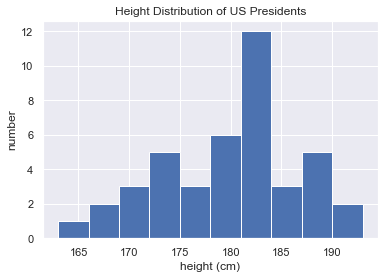

In [33]:
plt.hist(heights)
plt.title('Height Distribution of US Presidents')
plt.xlabel('height (cm)')
plt.ylabel('number');